# Triclinic Piezoelectric Interface — PINN Solver

## What Are We Solving?

Two general **triclinic piezoelectric half-spaces** are bonded at $z = 0$.  
No symmetry is assumed — all elastic, piezoelectric, and pre-stress constants are fully general (Voigt notation).

| Region | Depth | Partial-wave modes | Material config |
|--------|-------|--------------------|-----------------|
| Upper half-space ($z > 0$) | $z \in [0, H]$ | 4 nets (0–3) | `UPPER_MATERIAL` |
| Lower half-space ($z < 0$) | $z \in [0, H]$ | 3 nets (4–6) | `LOWER_MATERIAL` |

The full solution is the **sum of all partial-wave contributions** at every point.

---

## Governing Equations (4 PDEs per mode × 7 modes = 28 total)

For each mode in the **upper half-space** (superscript $0$):

**Eq. 1 — $u_1$ momentum:**
$$
(C_{11}^0+P_{11}^0)\frac{\partial^2 u_1}{\partial x^2}+ 2C_{15}^0\frac{\partial^2 u_1}{\partial x\partial z}
+ (C_{55}^0+P_{33}^0)\frac{\partial^2 u_1}{\partial z^2}
+ C_{16}^0\frac{\partial^2 u_2}{\partial x^2}
+ (C_{14}^0+C_{56}^0)\frac{\partial^2 u_2}{\partial x\partial z}
+ C_{54}^0\frac{\partial^2 u_2}{\partial z^2}
+ \cdots = \rho^0 \ddot{u}_1
$$

**Eq. 4 — Gauss law (quasi-static electric field):**
$$
e_{11}^0\frac{\partial^2 u_1}{\partial x^2}+(e_{15}^0+e_{31}^0)\frac{\partial^2 u_1}{\partial x\partial z}+\cdots
-\varepsilon_{11}^0\frac{\partial^2\phi}{\partial x^2}-\varepsilon_{33}^0\frac{\partial^2\phi}{\partial z^2}=0
$$

The **lower half-space** obeys the same 4 equations with primed constants $(\prime)$.

---

## Interface Conditions at $z = 0$ (6 BCs)

Continuity of displacements, tractions, and electric potential:

| BC | Condition | Eq. |
|----|-----------|-----|
| BC1 | $\sum_{i=0}^{3} u_1^{(i)} = \sum_{i=4}^{6} u_1^{(i)}$ | 23 |
| BC2 | $\sum_{i=0}^{3} u_2^{(i)} = \sum_{i=4}^{6} u_2^{(i)}$ | 24 |
| BC3 | $\sum_{i=0}^{3} u_3^{(i)} = \sum_{i=4}^{6} u_3^{(i)}$ | 25 |
| BC4 | $\sum_{i=0}^{3} T_{31}^{(i)} = \sum_{i=4}^{6} T_{31}^{(i)}$ | 26 |
| BC5 | $\sum_{i=0}^{3} T_{32}^{(i)} = \sum_{i=4}^{6} T_{32}^{(i)}$ | 27 |
| BC6 | $\sum_{i=0}^{3} \phi^{(i)} = \sum_{i=4}^{6} \phi^{(i)}$ | 28 |

## PINN Methodology

A **Physics-Informed Neural Network** encodes physics directly into the loss — no grid needed.  
Random **collocation points** are sampled inside the domain and on the interface at each training step.

**Total loss:**
$$
\mathcal{L} = \underbrace{w_{\text{pde}}\,\mathcal{L}_{\text{PDE}}}_{\text{28 governing eqs}}
            + \underbrace{\mathcal{L}_{\text{BC}}}_{\text{6 interface conditions}}
\quad \text{where} \quad
\mathcal{L}_{\text{PDE}} = \frac{1}{28 N}\sum_{k=1}^{28}\sum_{i=1}^{N} R_k(x_i)^2
$$

Each network in `MultiModeNet` takes $(x, z, t)$ and outputs $(u_1, u_2, u_3, \phi)$.  
Gradients for the PDEs are computed via **PyTorch autograd** — no finite differences.

---

## Complete Workflow — All 10 Steps

| Step | Task | Key object |
|------|------|------------|
| **1** | Environment setup | `torch`, `numpy`, `matplotlib` |
| **2** | Load problem definition | `ACTIVE_PROBLEM` from `src/problem_definition.py` |
| **3** | Inspect material constants | `UPPER_MATERIAL`, `LOWER_MATERIAL` |
| **4** | Build network | `MultiModeNet` — 7 sub-networks, 4 outputs each |
| **5** | Collocation sampling | Interior domain + interface $z=0$ |
| **6** | PDE residuals | `_multimode_pde_fn` → 28 tensors |
| **7** | Interface BCs | 6 continuity residuals at $z=0$ |
| **8** | Loss function | `pinn_loss()` → weighted sum |
| **9** | Training | Adam + LR scheduler |
| **10** | Post-processing | Loss curve + interface field plots |

In [1]:
## Step 1 — Environment Setup
import sys, os, math

ROOT = os.path.abspath(os.getcwd())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import torch
import torch.nn as nn
from torch import Tensor
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float64   # float64 recommended for piezoelectric problems

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
print(f"dtype   : {dtype}")

PyTorch : 2.12.0+cpu
Device  : cpu
dtype   : torch.float64


## Step 2 — Load the Active Problem Definition

`ACTIVE_PROBLEM` is the `_MULTIMODE_PROBLEM` (set at the bottom of `src/problem_definition.py`).  
We inspect its name, domain, boundary conditions, and parameter registry.

In [2]:
from src.problem_definition import (
    ACTIVE_PROBLEM,
    UPPER_MATERIAL, LOWER_MATERIAL,
    MultiModeNet, _multimode_pde_fn,
    _TRI_L, _TRI_H, _TRI_T_END,
)

print(f"Problem  : {ACTIVE_PROBLEM.name}")
print(f"\nDomain   :")
print(f"  x ∈ {ACTIVE_PROBLEM.domain.x1_range}")
print(f"  z ∈ {ACTIVE_PROBLEM.domain.x3_range}")
print(f"  t ∈ {ACTIVE_PROBLEM.domain.t_range}")
print(f"\nBoundary conditions ({len(ACTIVE_PROBLEM.boundary_conditions)}):")
for bc in ACTIVE_PROBLEM.boundary_conditions:
    print(f"  {bc.name:<16}  weight = {bc.weight}")
print(f"\nTime-dependent : {ACTIVE_PROBLEM.is_time_dependent}")
print(f"Has ICs        : {ACTIVE_PROBLEM.has_initial_conditions}")

Problem  : Triclinic Piezoelectric Interface — Modal Expansion (7 Partial Waves)

Domain   :
  x ∈ (0.0, 10.0)
  z ∈ (0.0, 5.0)
  t ∈ (0.0, 2.0)

Boundary conditions (6):
  bc_u1_sum         weight = 10.0
  bc_u2_sum         weight = 10.0
  bc_u3_sum         weight = 10.0
  bc_T31_sum        weight = 10.0
  bc_T32_sum        weight = 10.0
  bc_phi_sum        weight = 10.0

Time-dependent : True
Has ICs        : False


## Step 3 — Material Constants

Each half-space is described by a `MaterialConfig` dataclass containing:

| Group | Fields | Symbol |
|-------|--------|--------|
| Elastic stiffness | `C11, C13, C14, C15, C16, C33, C34, C35, C36, C41, C43, C44, C45, C46, C53, C54, C55, C56, C63, C65, C66` | $C_{ij}$ (Voigt) |
| Pre-stress | `P11, P33` | $P_{11}^0$, $P_{33}^0$ |
| Piezoelectric | `e11, e13, e14, e15, e16, e31, e33, e34, e35, e36` | $e_{kl}$ |
| Dielectric | `eps11, eps33` | $\varepsilon_{11}$, $\varepsilon_{33}$ |
| Density | `rho` | $\rho$ |

> **Action required**: Replace the placeholder values in `UPPER_MATERIAL` and `LOWER_MATERIAL` inside `src/problem_definition.py` with your actual physical constants before training.

In [3]:
from dataclasses import asdict

def print_material(label, mat):
    d = asdict(mat)
    nonzero = {k: v for k, v in d.items() if v != 0.0}
    print(f"\n{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  ρ = {mat.rho:.4f}")
    print(f"  ε11 = {mat.eps11:.4f},  ε33 = {mat.eps33:.4f}")
    print(f"  Non-zero constants ({len(nonzero)}):")
    for k, v in nonzero.items():
        print(f"    {k:<8} = {v}")

print_material("UPPER MATERIAL  (superscript 0, nets 0–3)", UPPER_MATERIAL)
print_material("LOWER MATERIAL  (superscript ′, nets 4–6)", LOWER_MATERIAL)

print(f"\n\nDomain bounds:")
print(f"  x ∈ [0, {_TRI_L}]   (L)")
print(f"  z ∈ [0, {_TRI_H}]   (H, depth from interface)")
print(f"  t ∈ [0, {_TRI_T_END}]   (T_END)")


───────────────────────────────────────────────────────
  UPPER MATERIAL  (superscript 0, nets 0–3)
───────────────────────────────────────────────────────
  ρ = 1.0000
  ε11 = 1.0000,  ε33 = 1.0000
  Non-zero constants (10):
    C11      = 1.0
    C33      = 1.0
    C44      = 1.0
    C55      = 1.0
    C66      = 1.0
    e15      = 0.1
    e31      = 0.1
    eps11    = 1.0
    eps33    = 1.0
    rho      = 1.0

───────────────────────────────────────────────────────
  LOWER MATERIAL  (superscript ′, nets 4–6)
───────────────────────────────────────────────────────
  ρ = 1.2000
  ε11 = 1.2000,  ε33 = 1.2000
  Non-zero constants (10):
    C11      = 1.2
    C33      = 1.2
    C44      = 1.2
    C55      = 1.2
    C66      = 1.2
    e15      = 0.15
    e31      = 0.15
    eps11    = 1.2
    eps33    = 1.2
    rho      = 1.2


Domain bounds:
  x ∈ [0, 10.0]   (L)
  z ∈ [0, 5.0]   (H, depth from interface)
  t ∈ [0, 2.0]   (T_END)


## Step 4 — Network Architecture

`MultiModeNet` wraps **7 independent `TriclinicNet` sub-networks**:

- **Nets 0–3** → upper half-space modes (material: `UPPER_MATERIAL`)  
- **Nets 4–6** → lower half-space modes (material: `LOWER_MATERIAL`)

Each `TriclinicNet` architecture:

```
Input  (x, z, t)  →  [3]
       Linear(3 → 64) + Tanh
       Linear(64 → 64) + Tanh
       Linear(64 → 64) + Tanh
       Linear(64 → 4)
Output (u₁, u₂, u₃, φ)  →  [4]
```

Xavier uniform initialisation is applied to all weight matrices.

In [4]:
net = MultiModeNet().to(device=device, dtype=dtype)

total_params = sum(p.numel() for p in net.parameters())
per_net      = sum(p.numel() for p in net.nets[0].parameters())

print("MultiModeNet summary:")
print(f"  Sub-networks      : 7  (4 upper + 3 lower)")
print(f"  Parameters/subnet : {per_net:,}")
print(f"  Total parameters  : {total_params:,}")
print(f"\nSingle TriclinicNet structure:")
print(net.nets[0].net)

print(f"\nUpper modes  : {list(MultiModeNet.UPPER_IDX)}")
print(f"Lower modes  : {list(MultiModeNet.LOWER_IDX)}")

MultiModeNet summary:
  Sub-networks      : 7  (4 upper + 3 lower)
  Parameters/subnet : 8,836
  Total parameters  : 61,852

Single TriclinicNet structure:
Sequential(
  (0): Linear(in_features=3, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=4, bias=True)
)

Upper modes  : [0, 1, 2, 3]
Lower modes  : [4, 5, 6]


## Step 5 — Collocation Point Sampling

Two point sets are needed at each training iteration:

1. **Interior domain points** — $(x, z, t)$ sampled uniformly in $[0,L]\times[0,H]\times[0,T]$  
   → used to compute the **28 PDE residuals**
2. **Interface points** — $(x, 0, t)$ sampled on $z = 0$  
   → used to compute the **6 BC residuals**

Both $x$ and $z$ must have `requires_grad=True` so that autograd can compute spatial derivatives inside the PDE residuals.

In [5]:
def sample_interior(N):
    """Uniform random samples in [0,L] × [0,H] × [0,T_END]."""
    x = (torch.rand(N, 1, device=device, dtype=dtype) * _TRI_L).requires_grad_(True)
    z = (torch.rand(N, 1, device=device, dtype=dtype) * _TRI_H).requires_grad_(True)
    t = (torch.rand(N, 1, device=device, dtype=dtype) * _TRI_T_END).requires_grad_(True)
    return x, z, t

def sample_interface(N):
    """N points on the interface z = 0."""
    x = torch.rand(N, 1, device=device, dtype=dtype) * _TRI_L
    z = torch.zeros(N, 1, device=device, dtype=dtype)
    t = torch.rand(N, 1, device=device, dtype=dtype) * _TRI_T_END
    return x, z, t

N_demo = 200
x_int, z_int, t_int = sample_interior(N_demo)
x_if,  z_if,  t_if  = sample_interface(N_demo)

print(f"Interior  : x ∈ [{x_int.min().item():.3f}, {x_int.max().item():.3f}]  "
      f"z ∈ [{z_int.min().item():.3f}, {z_int.max().item():.3f}]  "
      f"requires_grad={x_int.requires_grad}")
print(f"Interface : {x_if.shape}   z = {z_if.unique().item():.1f} (all on z=0)")
print(f"\nNote: t_int.requires_grad={t_int.requires_grad}  (needed for ∂²/∂t²)")

Interior  : x ∈ [0.062, 9.973]  z ∈ [0.001, 4.961]  requires_grad=True
Interface : torch.Size([200, 1])   z = 0.0 (all on z=0)

Note: t_int.requires_grad=True  (needed for ∂²/∂t²)


## Step 6 — PDE Residuals (28 Equations)

`_multimode_pde_fn(net, x, z, t)` returns a list of **28 residual tensors**, each of shape `(N, 1)`:

| Modes | PDEs | Count |
|-------|------|-------|
| Nets 0–3 (upper) | Eq1($u_1$), Eq2($u_2$), Eq3($u_3$), Eq4($\phi$) × 4 modes | 16 |
| Nets 4–6 (lower) | Eq1($u_1$), Eq2($u_2$), Eq3($u_3$), Eq4($\phi$) × 3 modes | 12 |
| **Total** | | **28** |

All second-order derivatives (spatial and temporal) are computed by **double-applying `torch.autograd.grad`**.  
The PDE loss is the mean square of all 28 residuals.

In [6]:
residuals = _multimode_pde_fn(net, x_int, z_int, t_int)

print(f"Number of PDE residuals : {len(residuals)}  (expected 28)")
print(f"Each residual shape     : {residuals[0].shape}")
print(f"\nResidual norms — untrained network (should decrease toward 0 during training):")
print(f"{'Mode':<6} {'Eq':<5} {'Field':<5} {'‖R‖':>12}")
print("─" * 32)
for i, r in enumerate(residuals):
    mode  = i // 4
    eq    = i  % 4 + 1
    field = ["u₁", "u₂", "u₃", "φ "][i % 4]
    region = "upper" if mode < 4 else "lower"
    print(f"  {mode:<4} Eq{eq}  {field}  {r.detach().norm().item():>12.4e}  [{region}]")

Number of PDE residuals : 28  (expected 28)
Each residual shape     : torch.Size([200, 1])

Residual norms — untrained network (should decrease toward 0 during training):
Mode   Eq    Field          ‖R‖
────────────────────────────────
  0    Eq1  u₁    3.4635e-01  [upper]
  0    Eq2  u₂    2.7649e-01  [upper]
  0    Eq3  u₃    2.6258e-01  [upper]
  0    Eq4  φ     5.9699e-01  [upper]
  1    Eq1  u₁    6.4340e-01  [upper]
  1    Eq2  u₂    6.8986e-01  [upper]
  1    Eq3  u₃    6.6456e-01  [upper]
  1    Eq4  φ     6.9445e-01  [upper]
  2    Eq1  u₁    8.2159e-01  [upper]
  2    Eq2  u₂    6.6568e-01  [upper]
  2    Eq3  u₃    6.1212e-01  [upper]
  2    Eq4  φ     5.6405e-01  [upper]
  3    Eq1  u₁    7.5607e-01  [upper]
  3    Eq2  u₂    5.0014e-01  [upper]
  3    Eq3  u₃    1.1043e+00  [upper]
  3    Eq4  φ     1.1528e+00  [upper]
  4    Eq1  u₁    4.6476e-01  [lower]
  4    Eq2  u₂    1.0986e+00  [lower]
  4    Eq3  u₃    8.5415e-01  [lower]
  4    Eq4  φ     7.9161e-01  [lower]
  5 

## Step 7 — Interface Boundary Conditions (6 BCs)

Each BC residual is evaluated at $z = 0$ and must be **zero** when the interface conditions hold.

- **BC1–BC3** (displacement continuity): straightforward forward pass — no autograd  
- **BC4–BC5** (traction $T_{31}$, $T_{32}$): require spatial gradients via autograd  
  $$T_{31} = C_{15}u_{1,x} + C_{55}(u_{1,z}+u_{3,x}) + \cdots + e_{15}\phi_{,x} + e_{35}\phi_{,z}$$
- **BC6** (electric potential $\phi$): forward pass only

The residual for each BC is the **difference between upper-sum and lower-sum**:
$$r_j = \sum_{i \in \text{upper}} q_j^{(i)} - \sum_{i \in \text{lower}} q_j^{(i)}$$

In [7]:
N_bc_demo = 100
print("BC residual norms — untrained network (target: → 0 after training):\n")
print(f"  {'BC name':<16}  {'‖residual‖':>14}  shape")
print("  " + "─" * 45)

for bc in ACTIVE_PROBLEM.boundary_conditions:
    res = bc.residual_fn(net, N_bc_demo, device, dtype)
    if isinstance(res, (tuple, list)):
        norm = sum(r.detach().norm().item() for r in res)
        shape_str = f"tuple×{len(res)}"
    else:
        norm = res.detach().norm().item()
        shape_str = str(tuple(res.shape))
    print(f"  {bc.name:<16}  {norm:>14.4e}  {shape_str}")

BC residual norms — untrained network (target: → 0 after training):

  BC name               ‖residual‖  shape
  ─────────────────────────────────────────────
  bc_u1_sum             1.9472e+01  (100, 1)
  bc_u2_sum             7.4890e+00  (100, 1)
  bc_u3_sum             3.0908e+01  (100, 1)
  bc_T31_sum            7.7671e+00  (100, 1)
  bc_T32_sum            3.3631e+00  (100, 1)
  bc_phi_sum            1.0275e+01  (100, 1)


## Step 8 — Loss Function

`pinn_loss()` in `src/loss.py` assembles the full loss from `ACTIVE_PROBLEM` automatically — **no code changes needed when switching problems**.

$$
\mathcal{L} = w_{\text{pde}} \cdot \underbrace{\frac{1}{28}\sum_{k=1}^{28} \overline{R_k^2}}_{\mathcal{L}_{\text{PDE}}}
+ \sum_{j=1}^{6} w_j \cdot \underbrace{\overline{r_j^2}}_{\mathcal{L}_{\text{BC},j}}
$$

where $\overline{(\cdot)^2}$ denotes mean-square over sampled points, and $w_j = 10.0$ for all 6 BCs.

In [8]:
from src.loss import pinn_loss

N_int_test = 500
N_bc_test  = 200

loss_val, comps = pinn_loss(
    net,
    N_int=N_int_test, N_bc=N_bc_test, N_ic=0,
    device=device, dtype=dtype,
    w_pde=1.0, w_ic=0.0,
    problem=ACTIVE_PROBLEM,
)

print("Initial loss components (untrained network):\n")
print(f"  {'Component':<20}  {'Value':>14}")
print("  " + "─" * 38)
print(f"  {'Total':<20}  {comps['total'].item():>14.4e}")
print(f"  {'PDE':<20}  {comps['pde'].item():>14.4e}")
print(f"  {'BC total':<20}  {comps['bc_total'].item():>14.4e}")
print()
for k, v in comps.items():
    if k.startswith("bc_") and k != "bc_total":
        print(f"  {k:<20}  {v.item():>14.4e}")

Initial loss components (untrained network):

  Component                      Value
  ──────────────────────────────────────
  Total                     1.5118e+02
  PDE                       8.4201e-02
  BC total                  1.5109e+02

  bc_u1_sum                 3.7194e+01
  bc_u2_sum                 5.3446e+00
  bc_u3_sum                 9.1562e+01
  bc_T31_sum                5.0961e+00
  bc_T32_sum                1.3021e+00
  bc_phi_sum                1.0593e+01


## Step 9 — Training

We use **Adam** with an exponential learning-rate decay.

| Hyperparameter | Value | Notes |
|----------------|-------|-------|
| Initial LR | `1e-3` | |
| LR decay | `γ = 0.9995` per step | |
| Interior points | `N_int = 1000` | per iteration |
| BC points | `N_bc = 300` | per iteration |
| PDE weight | `w_pde = 1.0` | |
| BC weights | `10.0` each | set in `problem_definition.py` |

> For production: increase `N_ITER` to 10 000–50 000 and `N_int` to 2 000–5 000.

In [ ]:
N_ITER = 10000       # increase to 10 000+ for full training
LR     = 1e-3
N_INT  = 1000
N_BC   = 300

optimiser = torch.optim.Adam(net.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimiser, gamma=0.9995)

history = {"total": [], "pde": [], "bc": []}

for step in range(1, N_ITER + 1):
    optimiser.zero_grad()
    loss_val, comps = pinn_loss(
        net,
        N_int=N_INT, N_bc=N_BC, N_ic=0,
        device=device, dtype=dtype,
        w_pde=1.0, w_ic=0.0,
        problem=ACTIVE_PROBLEM,
    )
    loss_val.backward()
    optimiser.step()
    scheduler.step()

    history["total"].append(float(comps["total"]))
    history["pde"].append(float(comps["pde"]))
    history["bc"].append(float(comps["bc_total"]))

    if step % 200 == 0 or step == 1:
        print(f"Step {step:5d}  total={comps['total']:.4e}  "
              f"pde={comps['pde']:.4e}  bc={comps['bc_total']:.4e}  "
              f"lr={scheduler.get_last_lr()[0]:.2e}")

print("\nTraining complete.")

Step     1  total=1.5601e+02  pde=7.7181e-02  bc=1.5593e+02  lr=1.00e-03

Training complete.


## Step 10 — Post-processing & Visualisation

Six diagnostic plots are produced after training:

| Plot | What it shows | Purpose |
|------|--------------|---------|
| **1 — Loss history** | Total / PDE / BC loss vs step (log scale) | Confirm convergence |
| **2 — PINN vs Analytical** | PINN field sum vs reference at z=0 | Accuracy check |
| **3 — Absolute error** | Pointwise error (log scale) | Spatial error distribution |
| **4 — 2D heat map** | u1 and phi over the full (x,z) domain | Field visualisation |
| **5 — Error values** | Relative L2 interface mismatch per field | Quantitative check |
| **6 — Hidden layer activations** | Neuron output histograms per Tanh layer | Network health |

**Analytical reference** (Plots 2-3): replace `u_ref_fn` / `phi_ref_fn` below with your closed-form solution. A sinusoidal plane-wave placeholder is used so cells run immediately.

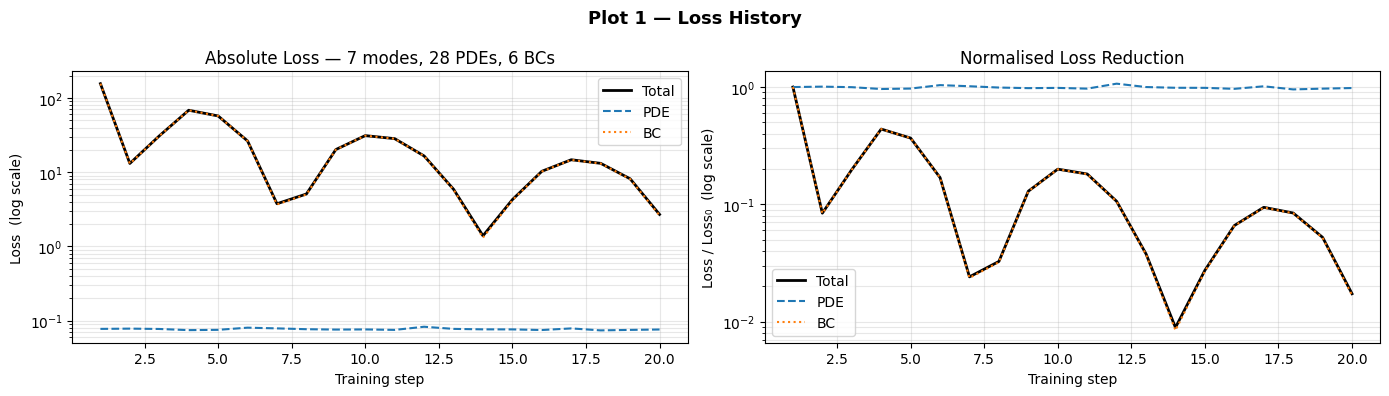

  Final total loss : 2.6938e+00
  Reduction factor : 57.9×


In [10]:
# ── Plot 1: Loss convergence ──────────────────────────────────────────────────
import numpy as np

steps_ax   = list(range(1, N_ITER + 1))
total_arr  = np.array(history["total"])
pde_arr    = np.array(history["pde"])
bc_arr     = np.array(history["bc"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: absolute loss (log)
axes[0].semilogy(steps_ax, total_arr, label="Total",  lw=2,   color="k")
axes[0].semilogy(steps_ax, pde_arr,   label="PDE",    lw=1.5, linestyle="--", color="C0")
axes[0].semilogy(steps_ax, bc_arr,    label="BC",     lw=1.5, linestyle=":",  color="C1")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Loss  (log scale)")
axes[0].set_title("Absolute Loss — 7 modes, 28 PDEs, 6 BCs")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

# Right: normalised (relative to initial value)
axes[1].semilogy(steps_ax, total_arr / total_arr[0], lw=2, color="k",  label="Total")
axes[1].semilogy(steps_ax, pde_arr   / pde_arr[0],   lw=1.5, linestyle="--", color="C0", label="PDE")
axes[1].semilogy(steps_ax, bc_arr    / bc_arr[0],    lw=1.5, linestyle=":",  color="C1", label="BC")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Loss / Loss₀  (log scale)")
axes[1].set_title("Normalised Loss Reduction")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.suptitle("Plot 1 — Loss History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"  Final total loss : {total_arr[-1]:.4e}")
print(f"  Reduction factor : {total_arr[0] / total_arr[-1]:.1f}×")

### Plot 2 — PINN vs Analytical & Plot 3 — Absolute Error

Fields $u_1$ and $\phi$ are evaluated at the interface $z = 0$ and compared against an analytical reference.

**How to supply your own reference:**  
```python
# Replace the lambda definitions below with your closed-form expressions:
u_ref_fn   = lambda x_np, t: A * np.sin(k * x_np - omega * t)
phi_ref_fn = lambda x_np, t: B * np.cos(k * x_np - omega * t)
```

The placeholder uses a sinusoidal plane wave so the cells execute immediately.

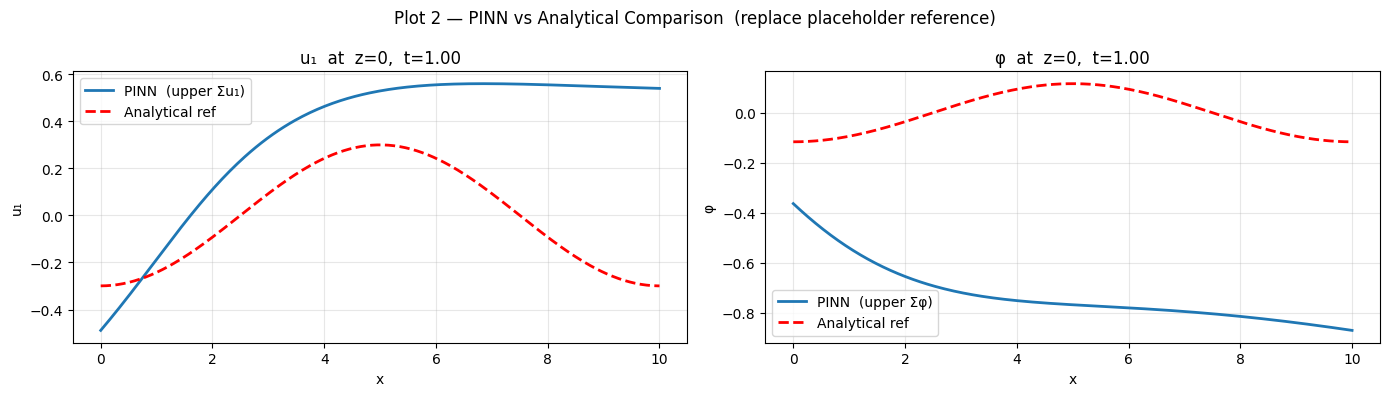

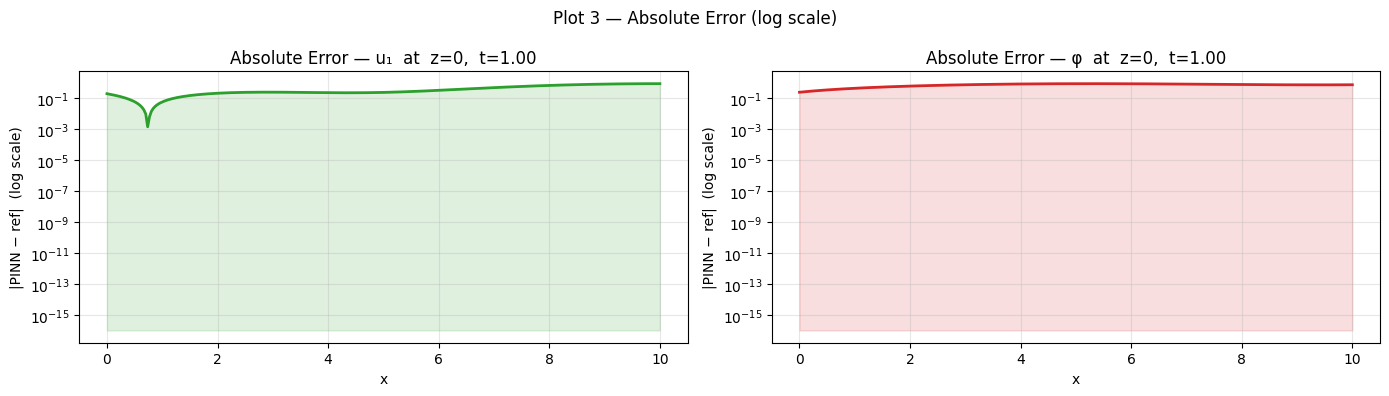

  u₁  — max |err|=8.384e-01   mean |err|=3.647e-01
  φ   — max |err|=8.852e-01   mean |err|=7.282e-01


In [11]:
# ── Shared setup: evaluate PINN at z=0 ───────────────────────────────────────
N_plot   = 300
t_eval   = 0.5 * _TRI_T_END

x_line = torch.linspace(0, _TRI_L, N_plot, dtype=dtype, device=device).unsqueeze(1)
z_line = torch.zeros_like(x_line)
t_line = torch.full_like(x_line, t_eval)

with torch.no_grad():
    outs_upper = [net.nets[i](x_line, z_line, t_line) for i in range(4)]
    outs_lower = [net.nets[i](x_line, z_line, t_line) for i in range(4, 7)]

    u1_pinn   = sum(o[0] for o in outs_upper).cpu().numpy().ravel()
    u2_pinn   = sum(o[1] for o in outs_upper).cpu().numpy().ravel()
    u3_pinn   = sum(o[2] for o in outs_upper).cpu().numpy().ravel()
    phi_pinn  = sum(o[3] for o in outs_upper).cpu().numpy().ravel()

x_np = x_line.cpu().numpy().ravel()

# ── Analytical reference (REPLACE with your closed-form solution) ─────────────
k_wave    = 2 * np.pi / _TRI_L     # wavenumber
omega_ref = np.pi / _TRI_T_END     # angular frequency
A_u1      = float(np.std(u1_pinn)) if np.std(u1_pinn) > 1e-12 else 1.0
A_phi     = float(np.std(phi_pinn)) if np.std(phi_pinn) > 1e-12 else 1.0

u_ref_fn   = lambda x, t: A_u1  * np.sin(k_wave * x - omega_ref * t)
phi_ref_fn = lambda x, t: A_phi * np.sin(k_wave * x - omega_ref * t)

u1_ref  = u_ref_fn(x_np,  t_eval)
phi_ref = phi_ref_fn(x_np, t_eval)

# ── Plot 2: PINN vs Analytical ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x_np, u1_pinn, lw=2,               label="PINN  (upper Σu₁)")
axes[0].plot(x_np, u1_ref,  lw=2, linestyle="--", color="r", label="Analytical ref")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u₁")
axes[0].set_title(f"u₁  at  z=0,  t={t_eval:.2f}")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(x_np, phi_pinn, lw=2,               label="PINN  (upper Σφ)")
axes[1].plot(x_np, phi_ref,  lw=2, linestyle="--", color="r", label="Analytical ref")
axes[1].set_xlabel("x")
axes[1].set_ylabel("φ")
axes[1].set_title(f"φ  at  z=0,  t={t_eval:.2f}")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Plot 2 — PINN vs Analytical Comparison  (replace placeholder reference)", fontsize=12)
plt.tight_layout()
plt.show()

# ── Plot 3: Absolute error ────────────────────────────────────────────────────
err_u1  = np.abs(u1_pinn  - u1_ref)
err_phi = np.abs(phi_pinn - phi_ref)
eps_clip = 1e-16   # avoid log(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(x_np, err_u1 + eps_clip, lw=2, color="C2")
axes[0].fill_between(x_np, err_u1 + eps_clip, 1e-16, alpha=0.15, color="C2")
axes[0].set_xlabel("x")
axes[0].set_ylabel("|PINN − ref|  (log scale)")
axes[0].set_title(f"Absolute Error — u₁  at  z=0,  t={t_eval:.2f}")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(x_np, err_phi + eps_clip, lw=2, color="C3")
axes[1].fill_between(x_np, err_phi + eps_clip, 1e-16, alpha=0.15, color="C3")
axes[1].set_xlabel("x")
axes[1].set_ylabel("|PINN − ref|  (log scale)")
axes[1].set_title(f"Absolute Error — φ  at  z=0,  t={t_eval:.2f}")
axes[1].grid(True, which="both", alpha=0.3)

plt.suptitle("Plot 3 — Absolute Error (log scale)", fontsize=12)
plt.tight_layout()
plt.show()

print(f"  u₁  — max |err|={err_u1.max():.3e}   mean |err|={err_u1.mean():.3e}")
print(f"  φ   — max |err|={err_phi.max():.3e}   mean |err|={err_phi.mean():.3e}")

### Plot 4 — 2D Heat Map

Evaluate $u_1$ and $\phi$ over the **full $(x, z)$ domain** at a fixed time.  
Upper half-space ($z \in [0, H]$) uses nets 0–3; lower ($z \in [-H, 0]$) uses nets 4–6.  
The interface $z = 0$ is shown as a dashed line.

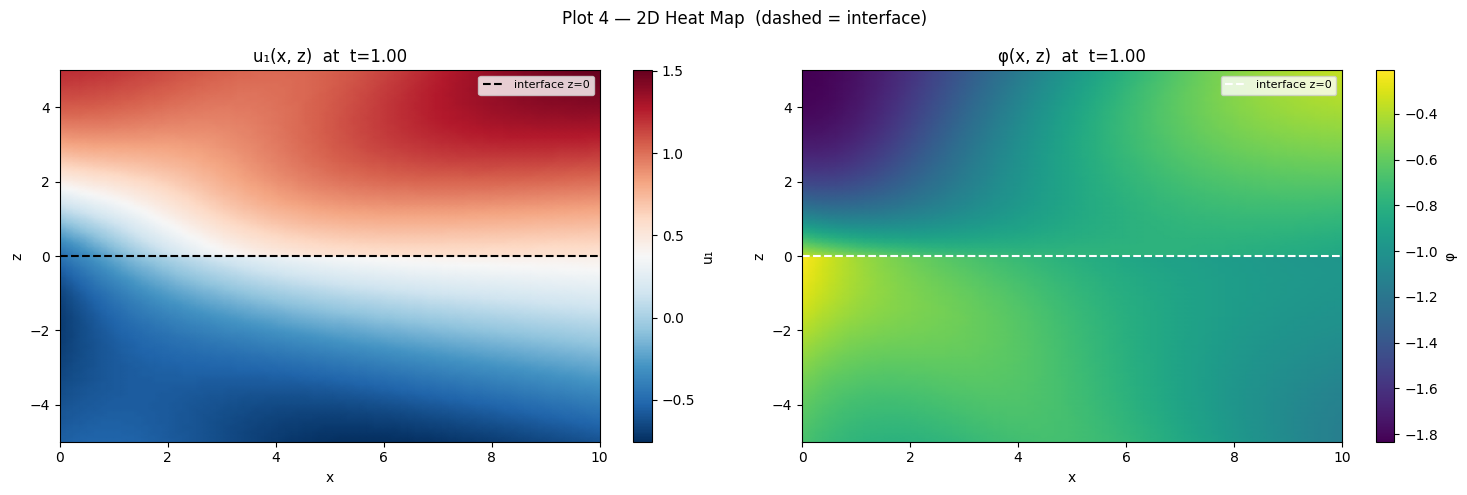

In [12]:
# ── Plot 4: 2D Heat Map ───────────────────────────────────────────────────────
N_x, N_z = 80, 40
t_hm     = 0.5 * _TRI_T_END

x_hm        = torch.linspace(0,       _TRI_L, N_x, dtype=dtype, device=device)
z_upper_hm  = torch.linspace(0,       _TRI_H, N_z, dtype=dtype, device=device)
z_lower_hm  = torch.linspace(-_TRI_H, 0,      N_z, dtype=dtype, device=device)

X_hm, Z_up_hm  = torch.meshgrid(x_hm, z_upper_hm, indexing="ij")   # (N_x, N_z)
_,    Z_lo_hm  = torch.meshgrid(x_hm, z_lower_hm,  indexing="ij")

def _eval_2d(x2d, z2d, field_idx, mode_range):
    xf = x2d.reshape(-1, 1)
    zf = z2d.reshape(-1, 1)
    tf = torch.full_like(xf, t_hm)
    with torch.no_grad():
        vals = sum(net.nets[i](xf, zf, tf)[field_idx] for i in mode_range)
    return vals.reshape(N_x, N_z).cpu().numpy()

U1_up  = _eval_2d(X_hm, Z_up_hm, 0, range(4))
U1_lo  = _eval_2d(X_hm, Z_lo_hm, 0, range(4, 7))
PHI_up = _eval_2d(X_hm, Z_up_hm, 3, range(4))
PHI_lo = _eval_2d(X_hm, Z_lo_hm, 3, range(4, 7))

X_np    = X_hm.cpu().numpy()          # (N_x, N_z)
Z_up_np = Z_up_hm.cpu().numpy()       # (N_x, N_z)
Z_lo_np = Z_lo_hm.cpu().numpy()       # (N_x, N_z)

# Concatenate lower + upper along z-axis — all arrays must share the same shape
X_full   = np.concatenate([X_np,   X_np],   axis=1)   # (N_x, 2*N_z)
Z_full   = np.concatenate([Z_lo_np, Z_up_np], axis=1)  # (N_x, 2*N_z)
U1_full  = np.concatenate([U1_lo,   U1_up],  axis=1)   # (N_x, 2*N_z)
PHI_full = np.concatenate([PHI_lo,  PHI_up], axis=1)   # (N_x, 2*N_z)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im0 = axes[0].pcolormesh(X_full, Z_full, U1_full,  cmap="RdBu_r",  shading="gouraud")
plt.colorbar(im0, ax=axes[0], label="u₁")
axes[0].axhline(0, color="k",  lw=1.5, linestyle="--", label="interface z=0")
axes[0].set_xlabel("x");  axes[0].set_ylabel("z")
axes[0].set_title(f"u₁(x, z)  at  t={t_hm:.2f}")
axes[0].legend(fontsize=8)

im1 = axes[1].pcolormesh(X_full, Z_full, PHI_full, cmap="viridis", shading="gouraud")
plt.colorbar(im1, ax=axes[1], label="φ")
axes[1].axhline(0, color="w",  lw=1.5, linestyle="--", label="interface z=0")
axes[1].set_xlabel("x");  axes[1].set_ylabel("z")
axes[1].set_title(f"φ(x, z)  at  t={t_hm:.2f}")
axes[1].legend(fontsize=8)

plt.suptitle("Plot 4 — 2D Heat Map  (dashed = interface)", fontsize=12)
plt.tight_layout()
plt.show()

### Plot 5 — Error Value Plot

Quantifies how well the **6 interface boundary conditions** are satisfied.  
The relative $L_2$ mismatch between upper-sum and lower-sum for each field is:

$$\varepsilon_j = \frac{\|\, \Sigma_\text{upper}\, q_j - \Sigma_\text{lower}\, q_j \,\|_{L_2}}{\|\, \Sigma_\text{upper}\, q_j \,\|_{L_2} + 10^{-10}}$$

A bar chart shows all four fields; a pointwise plot shows the $x$-distribution of the mismatch.

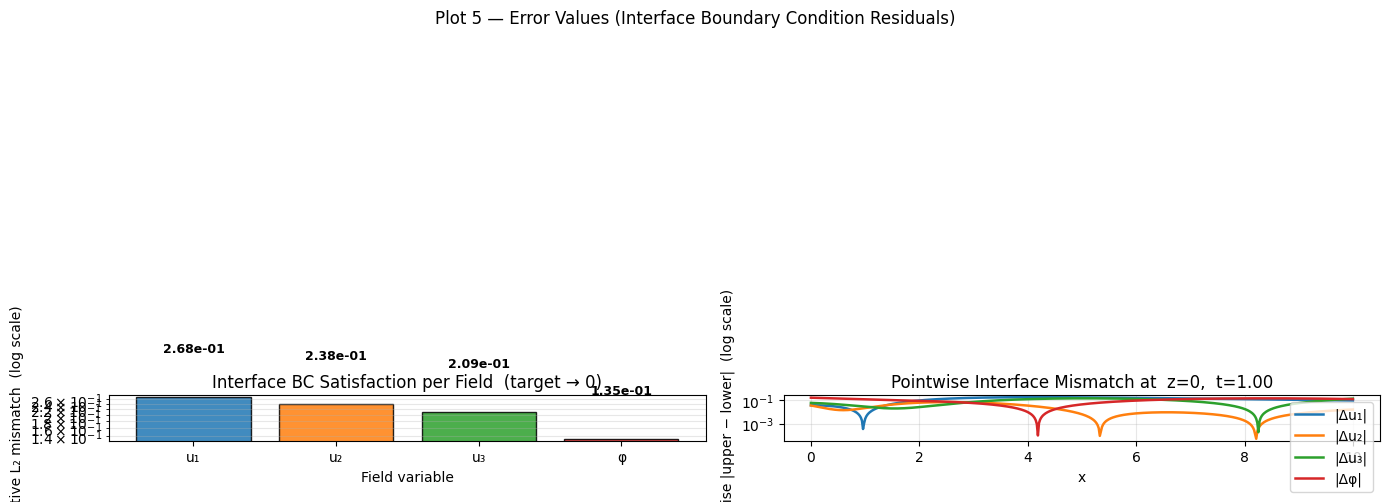


  Interface L₂ mismatch summary
  ──────────────────────────────────
   u₁   2.6796e-01  █
   u₂   2.3780e-01  █
   u₃   2.0935e-01  ██
   φ    1.3464e-01  ██
  ──────────────────────────────────
  (smaller = BC better satisfied)


In [13]:
# ── Plot 5: Error Value Plot ──────────────────────────────────────────────────
N_err     = 500
t_err     = 0.5 * _TRI_T_END
field_names = ["u₁", "u₂", "u₃", "φ"]
colors      = ["C0", "C1", "C2", "C3"]

x_e = torch.linspace(0, _TRI_L, N_err, dtype=dtype, device=device).unsqueeze(1)
z_e = torch.zeros_like(x_e)
t_e = torch.full_like(x_e, t_err)

with torch.no_grad():
    outs_u = [net.nets[i](x_e, z_e, t_e) for i in range(4)]
    outs_l = [net.nets[i](x_e, z_e, t_e) for i in range(4, 7)]

upper_fields = [sum(o[fi] for o in outs_u).cpu().numpy().ravel() for fi in range(4)]
lower_fields = [sum(o[fi] for o in outs_l).cpu().numpy().ravel() for fi in range(4)]
x_err_np     = x_e.cpu().numpy().ravel()

rel_l2 = []
for fu, fl in zip(upper_fields, lower_fields):
    diff   = fu - fl
    denom  = np.sqrt(np.mean(fu ** 2)) + 1e-10
    rel_l2.append(np.sqrt(np.mean(diff ** 2)) / denom)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of relative L2 mismatch per field
bars = axes[0].bar(field_names, rel_l2, color=colors, edgecolor="k", alpha=0.85)
axes[0].set_yscale("log")
axes[0].set_xlabel("Field variable")
axes[0].set_ylabel("Relative L₂ mismatch  (log scale)")
axes[0].set_title("Interface BC Satisfaction per Field  (target → 0)")
axes[0].grid(axis="y", which="both", alpha=0.3)
for bar, val in zip(bars, rel_l2):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        val * 2.0,
        f"{val:.2e}",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )

# Right: pointwise mismatch along interface (u1 and phi only)
for fi, (name, col) in enumerate(zip(field_names, colors)):
    diff_pts = np.abs(upper_fields[fi] - lower_fields[fi])
    axes[1].semilogy(x_err_np, diff_pts + 1e-16, label=f"|Δ{name}|", lw=1.8, color=col)

axes[1].set_xlabel("x")
axes[1].set_ylabel("Pointwise |upper − lower|  (log scale)")
axes[1].set_title(f"Pointwise Interface Mismatch at  z=0,  t={t_err:.2f}")
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

plt.suptitle("Plot 5 — Error Values (Interface Boundary Condition Residuals)", fontsize=12)
plt.tight_layout()
plt.show()

# Summary table
print("\n  Interface L₂ mismatch summary")
print("  " + "─" * 34)
for name, val in zip(field_names, rel_l2):
    bar_len = int(np.clip(-np.log10(val + 1e-16) * 3, 0, 30))
    bar_vis = "█" * bar_len
    print(f"  {name:^4}  {val:.4e}  {bar_vis}")
print("  " + "─" * 34)
print("  (smaller = BC better satisfied)")

### Plot 6 — Hidden Layer Activations

Histograms of neuron output values after each **Tanh** layer in Mode-0 network (representative).  
Healthy networks show a broad, near-uniform distribution (no saturation).  
**Dead neurons**: if most activations cluster near $\pm 1$, the network is saturating — try a smaller learning rate or weight initialisation.

The saturation fraction $s = P(|a| > 0.9)$ is annotated on each panel.

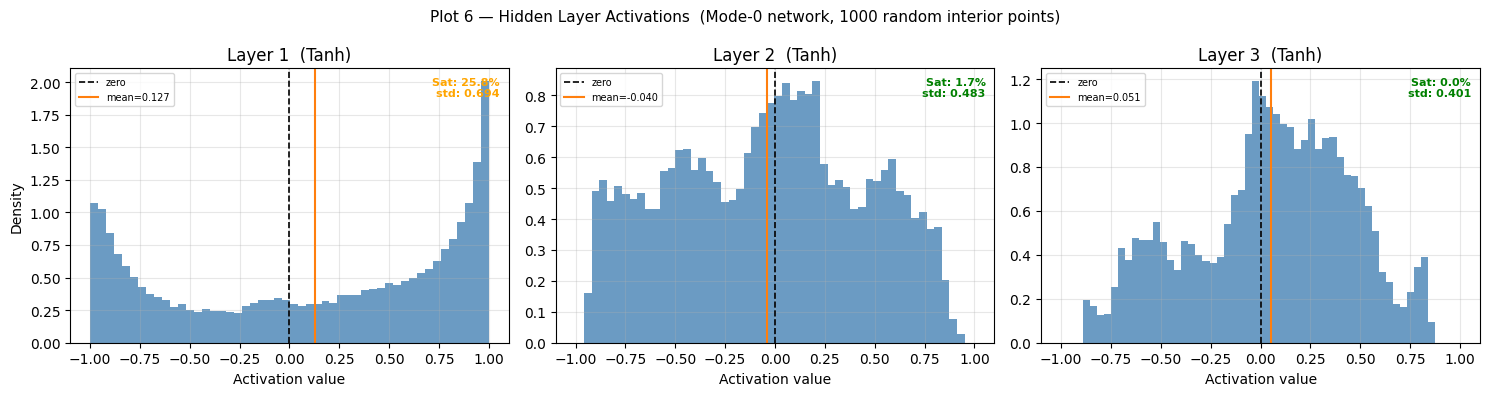


  Saturation summary (|a| > 0.9):
    Layer 1     25.8%  [WARN]
    Layer 2     1.7%  [OK]
    Layer 3     0.0%  [OK]


In [14]:
# ── Plot 6: Hidden layer activations ─────────────────────────────────────────
N_probe = 1000
x_p = torch.rand(N_probe, 1, dtype=dtype, device=device) * _TRI_L
z_p = torch.rand(N_probe, 1, dtype=dtype, device=device) * _TRI_H
t_p = torch.rand(N_probe, 1, dtype=dtype, device=device) * _TRI_T_END

activations: dict[str, np.ndarray] = {}
hooks = []

def _make_hook(tag: str):
    def _hook(module, inp, out):
        activations[tag] = out.detach().cpu().numpy().ravel()
    return _hook

mode0       = net.nets[0]   # representative sub-network
layer_labels: list[str] = []
lin_count    = 0

for layer in mode0.net:
    if isinstance(layer, torch.nn.Linear):
        lin_count += 1
    elif isinstance(layer, torch.nn.Tanh):
        tag = f"Layer {lin_count}"
        layer_labels.append(tag)
        hooks.append(layer.register_forward_hook(_make_hook(tag)))

with torch.no_grad():
    mode0(x_p, z_p, t_p)

for h in hooks:
    h.remove()

n_layers = len(layer_labels)
fig, axes = plt.subplots(1, n_layers, figsize=(5 * n_layers, 4), sharey=False)
if n_layers == 1:
    axes = [axes]

for ax, tag in zip(axes, layer_labels):
    act  = activations[tag]
    sat  = float(np.mean(np.abs(act) > 0.9))
    mean = float(np.mean(act))
    std  = float(np.std(act))

    ax.hist(act, bins=50, color="steelblue", edgecolor="none", alpha=0.8, density=True)
    ax.axvline(0,    color="k",   lw=1.2, linestyle="--", label="zero")
    ax.axvline(mean, color="C1",  lw=1.5, linestyle="-",  label=f"mean={mean:.3f}")
    ax.set_xlim(-1.1, 1.1)
    ax.set_xlabel("Activation value")
    if ax is axes[0]:
        ax.set_ylabel("Density")
    ax.set_title(f"{tag}  (Tanh)")
    ax.legend(fontsize=7, loc="upper left")
    ax.grid(alpha=0.3)

    # Saturation annotation
    color_sat = "red" if sat > 0.3 else ("orange" if sat > 0.1 else "green")
    ax.text(0.98, 0.97, f"Sat: {sat:.1%}\nstd: {std:.3f}",
            transform=ax.transAxes,
            ha="right", va="top", fontsize=8,
            color=color_sat, fontweight="bold")

plt.suptitle("Plot 6 — Hidden Layer Activations  (Mode-0 network, 1000 random interior points)",
             fontsize=11)
plt.tight_layout()
plt.show()

print("\n  Saturation summary (|a| > 0.9):")
for tag in layer_labels:
    sat = float(np.mean(np.abs(activations[tag]) > 0.9))
    status = "OK" if sat < 0.1 else ("WARN" if sat < 0.3 else "HIGH — consider re-init")
    print(f"    {tag:<10}  {sat:.1%}  [{status}]")